# Лабораторная работа
## Плохоформализуемые задачи на примере подбора гиперпараметров деревьев решений

В работе задача подбора гиперпараметров модели машинного обучения рассматривается
как пример **плохоформализуемой задачи**.

**План работы:**
1. Определение плохоформализуемой задачи.
2. Формализация задачи подбора гиперпараметров.
3. Обоснование плохой формализуемости целевой функции.
4. Реализация и сравнение трёх методов поиска оптимума:
   - Grid Search;
   - генетический алгоритм;
   - байесовская оптимизация (Optuna / TPE).
5. Сравнительный эксперимент и выводы.

## 1. Определение плохоформализуемой задачи

**Плохоформализуемая задача** — это задача оптимизации, для которой целевая функция
$F(\lambda)$ не имеет явного аналитического выражения: по входу $\lambda$ можно
получить значение $F(\lambda)$, но нельзя выписать формулу или вычислить
производные.

**Характерные свойства:**

- **Отсутствие аналитической формы решения** — нет замкнутого выражения $F(\lambda)$,
  оптимум нельзя найти, приравняв производную к нулю.
- **Невозможность вычисления градиента** — $\nabla_\lambda F(\lambda)$ не определён
  (часть параметров дискретна/категориальна, функция негладкая).
- **Высокая стоимость одного вычисления функции** — каждое значение $F(\lambda)$
  требует полного обучения модели (и кросс-валидации).
- **Стохастичность и шум наблюдений** — обучение использует случайность (SGD,
  bootstrap, перемешивание), поэтому повторный замер $F(\lambda)$ даёт разные значения.
- **Экспоненциальный размер пространства поиска** — число комбинаций гиперпараметров
  растёт как $O(n^k)$ по числу параметров $k$.

## 2. Формализация задачи подбора гиперпараметров

Введём обозначения:

- $\lambda \in \Lambda$ — вектор **гиперпараметров** модели (например,
  `max_depth`, `min_samples_split`, `min_samples_leaf`, `criterion`);
- $A(\lambda)$ — **процедура обучения** модели при фиксированных гиперпараметрах $\lambda$;
- $w^*(\lambda)$ — **оптимальные веса** (параметры) модели, найденные обучением:
$$
w^*(\lambda) = \arg\min_{w} \mathcal{L}\big(w; \lambda, \mathcal{D}_{\text{train}}\big);
$$
- $Q(\cdot)$ — **функция качества** модели на отложенных данных
  (Accuracy / F1 / AUC).

**Целевая функция** (качество обученной модели):
$$
F(\lambda) = Q\big(A(\lambda)\big) = Q\big(w^*(\lambda)\big).
$$

**Задача оптимизации** — найти гиперпараметры, максимизирующие качество:
$$
\lambda^* = \arg\max_{\lambda \in \Lambda} F(\lambda).
$$

## 3. Обоснование плохой формализуемости

Почему задача подбора $\lambda$ является плохоформализуемой:

1. **Нет аналитического выражения.** $F(\lambda)$ — результат композиции нескольких
   процедур, а не формула:
   $$
   F(\lambda) = \underbrace{Q}_{\text{метрика}} \circ
   \underbrace{A}_{\text{обучение}} \circ
   \underbrace{(\cdot)}_{\text{выбор } \lambda}.
   $$

2. **Нет доступа к градиентам:**
   $$
   \nabla_\lambda F(\lambda)\ \text{не определён},
   $$
   так как часть гиперпараметров дискретна (`max_depth`) или категориальна
   (`criterion`), а сама функция кусочно-постоянна.

3. **Стохастичность.** Внутри $A(\lambda)$ присутствуют случайные элементы
   (bootstrap, перемешивание, SGD), поэтому $F(\lambda)$ — зашумлённая величина:
   $$
   F(\lambda) = \mathbb{E}[\,\hat F(\lambda)\,] + \varepsilon,\qquad
   \varepsilon \sim \text{noise}.
   $$

4. **Дискретность и негладкость.** Малое изменение `max_depth` ($d \to d+1$)
   перестраивает структуру дерева целиком и может резко изменить качество —
   функция негладкая и меняется скачкообразно.

5. **Высокая стоимость.** Одна оценка $F(\lambda)$ требует полного обучения модели
   (и $k$-кратной кросс-валидации), поэтому бюджет вычислений ограничен.

Ниже мы **эмпирически** покажем негладкость $F(\lambda)$ по `max_depth`.

In [1]:
import time
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.tree import DecisionTreeClassifier

import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)
warnings.filterwarnings("ignore")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
print("Окружение готово. Optuna:", optuna.__version__)

Окружение готово. Optuna: 4.9.0


## 4. Постановка эксперимента

**Датасет.** Стандартный датасет `breast_cancer` из `sklearn` (бинарная
классификация: доброкачественная / злокачественная опухоль).

**Модель.** `DecisionTreeClassifier`.

**Единое пространство гиперпараметров $\Lambda$** для всех методов:

| Гиперпараметр | Тип | Область значений |
|---|---|---|
| `max_depth` | целочисленный | $\{2, 3, \dots, 20\}$ |
| `min_samples_split` | целочисленный | $\{2, 3, \dots, 20\}$ |
| `min_samples_leaf` | целочисленный | $\{1, 2, \dots, 20\}$ |
| `criterion` | категориальный | $\{\text{gini},\ \text{entropy}\}$ |

**Оценка качества** $F(\lambda)$ — средняя Accuracy по стратифицированной
5-кратной кросс-валидации.

In [2]:
data = load_breast_cancer()
X, y = data.data, data.target
print("Размер выборки:", X.shape, "| Классов:", len(np.unique(y)))

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# Единое пространство гиперпараметров (область значений)
SPACE = {
    "max_depth":         list(range(2, 21)),   # 19 значений
    "min_samples_split": list(range(2, 21)),   # 19 значений
    "min_samples_leaf":  list(range(1, 21)),   # 20 значений
    "criterion":         ["gini", "entropy"],  # 2 значения
}

# Счётчик числа оценок целевой функции (вызовов обучения модели)
N_EVALS = {"count": 0}

def objective(params):
    # Целевая функция F(lambda) = средняя Accuracy по 5-fold CV.
    # Это и есть плохоформализуемая целевая функция: на вход — гиперпараметры,
    # на выход — число; формулы и градиента нет.
    N_EVALS["count"] += 1
    model = DecisionTreeClassifier(random_state=RANDOM_STATE, **params)
    scores = cross_val_score(model, X, y, cv=cv, scoring="accuracy", n_jobs=-1)
    return scores.mean()

# Проверка: одна оценка функции
demo = objective({"max_depth": 5, "min_samples_split": 2,
                  "min_samples_leaf": 1, "criterion": "gini"})
print(f"Пример F(lambda) при max_depth=5: {demo:.4f}")
N_EVALS["count"] = 0  # сброс счётчика после демонстрации

Размер выборки: (569, 30) | Классов: 2
Пример F(lambda) при max_depth=5: 0.9280


### Иллюстрация негладкости и шума $F(\lambda)$

Зафиксируем все параметры, кроме `max_depth`, и построим зависимость
$F(\text{max\_depth})$. Видно, что функция **негладкая**: качество скачет при
изменении глубины на единицу — это прямое следствие перестройки структуры дерева.

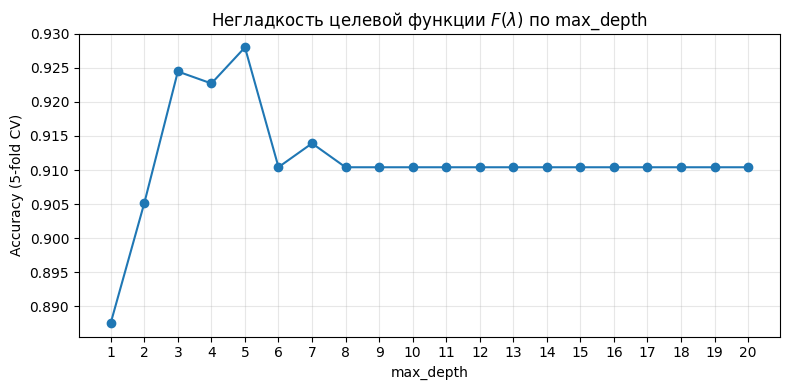

Градиент не определён: функция кусочно-постоянна и негладкая.


In [3]:
depths = list(range(1, 21))
quality = [objective({"max_depth": d, "min_samples_split": 2,
                      "min_samples_leaf": 1, "criterion": "gini"})
           for d in depths]
N_EVALS["count"] = 0  # это вспомогательный график, не учитываем в бюджете

plt.figure(figsize=(8, 4))
plt.plot(depths, quality, marker="o")
plt.title(r"Негладкость целевой функции $F(\lambda)$ по max_depth")
plt.xlabel("max_depth"); plt.ylabel("Accuracy (5-fold CV)")
plt.grid(alpha=0.3); plt.xticks(depths)
plt.tight_layout(); plt.show()

print("Градиент не определён: функция кусочно-постоянна и негладкая.")

## 5. Метод 1 — Grid Search (полный перебор)

**Идея.** Задаётся дискретная сетка значений по каждому гиперпараметру, после чего
перебираются **все** комбинации, и для каждой вычисляется $F(\lambda)$ через
кросс-валидацию.

**Формальная запись.** Пусть $\Lambda = \Lambda_1 \times \dots \times \Lambda_k$ —
декартово произведение сеток. Тогда:
$$
\lambda^*_{\text{grid}} = \arg\max_{\lambda \in \Lambda_1 \times \dots \times \Lambda_k}
F(\lambda).
$$

**Сложность.** Если по каждому из $k$ параметров взято $n$ значений, число оценок
функции равно
$$
O(n^k).
$$

**Вычислительная неэффективность.** Число вычислений растёт **экспоненциально** по
числу гиперпараметров. Полный перебор всего нашего пространства
($19 \times 19 \times 20 \times 2 = 14\,440$ комбинаций) при дорогой оценке функции
практически невыполним, поэтому на практике берут **огрублённую сетку** — но тогда
оптимум между узлами сетки теряется.

In [4]:
import itertools

# Огрублённая сетка (полный перебор всего пространства слишком дорог)
grid = {
    "max_depth":         [3, 5, 8, 12, 16, 20],
    "min_samples_split": [2, 5, 10, 20],
    "min_samples_leaf":  [1, 3, 6, 12],
    "criterion":         ["gini", "entropy"],
}
n_combos = np.prod([len(v) for v in grid.values()])
print(f"Размер сетки: {n_combos} комбинаций "
      f"({' x '.join(str(len(v)) for v in grid.values())})")

N_EVALS["count"] = 0
t0 = time.perf_counter()

grid_history = []     # лучшее качество к моменту i-й оценки
best_grid, best_grid_params = -np.inf, None
keys = list(grid.keys())
for combo in itertools.product(*grid.values()):
    params = dict(zip(keys, combo))
    score = objective(params)
    if score > best_grid:
        best_grid, best_grid_params = score, params
    grid_history.append(best_grid)

grid_time = time.perf_counter() - t0
grid_evals = N_EVALS["count"]

print(f"\nGrid Search:")
print(f"  accuracy : {best_grid:.4f}")
print(f"  params   : {best_grid_params}")
print(f"  оценок F : {grid_evals}")
print(f"  время    : {grid_time:.2f} c")

Размер сетки: 192 комбинаций (6 x 4 x 4 x 2)



Grid Search:
  accuracy : 0.9385
  params   : {'max_depth': 5, 'min_samples_split': 2, 'min_samples_leaf': 1, 'criterion': 'entropy'}
  оценок F : 192
  время    : 7.41 c


## 6. Метод 2 — Генетический алгоритм

**Идея.** Эволюционный поиск, имитирующий естественный отбор. Гиперпараметры
кодируются **хромосомой**, популяция кандидатов эволюционирует через отбор,
скрещивание и мутацию.

**Представление (хромосома).**
$$
\lambda = (\text{max\_depth},\ \text{min\_samples\_split},\
\text{min\_samples\_leaf},\ \text{criterion}).
$$

**Этапы:**

- **Функция приспособленности (fitness):** $\text{fitness}(\lambda) = F(\lambda)$.
- **Selection** — отбор лучших особей (здесь — турнирный отбор).
- **Crossover** — обмен генами между двумя родителями.
- **Mutation** — случайное изменение отдельных генов для исследования пространства.

**Сложность.** При $T$ поколениях, популяции $N$ и стоимости одной оценки $C$:
$$
O(T \cdot N \cdot C).
$$
Стоимость целиком определяется $C$ — ценой обучения модели. Генетические алгоритмы
применимы к плохоформализуемым задачам, поскольку **не требуют градиента** и работают с
любыми (в т.ч. дискретными/категориальными) пространствами.

In [5]:
rng = np.random.default_rng(RANDOM_STATE)

def random_individual():
    return {k: rng.choice(v).item() if k != "criterion" else str(rng.choice(v))
            for k, v in SPACE.items()}

def fitness(ind):
    return objective(ind)

def tournament_select(pop, scores, k=3):
    idx = rng.choice(len(pop), size=k, replace=False)
    best = idx[np.argmax([scores[i] for i in idx])]
    return pop[best]

def crossover(p1, p2):
    # равномерное скрещивание: каждый ген берём от случайного родителя
    return {k: (p1[k] if rng.random() < 0.5 else p2[k]) for k in SPACE}

def mutate(ind, rate=0.3):
    child = dict(ind)
    for k, v in SPACE.items():
        if rng.random() < rate:
            child[k] = str(rng.choice(v)) if k == "criterion" else rng.choice(v).item()
    return child

# Параметры ГА
POP_SIZE, N_GEN, ELITE = 12, 8, 2

N_EVALS["count"] = 0
t0 = time.perf_counter()

population = [random_individual() for _ in range(POP_SIZE)]
scores = [fitness(ind) for ind in population]
ga_history = []
best_ga = max(scores)
ga_history.extend([max(ga_history[-1] if ga_history else -np.inf, s) for s in
                   np.maximum.accumulate(scores)])

for gen in range(N_GEN):
    # элитизм: лучшие особи переходят без изменений
    order = np.argsort(scores)[::-1]
    new_pop = [population[i] for i in order[:ELITE]]
    while len(new_pop) < POP_SIZE:
        p1 = tournament_select(population, scores)
        p2 = tournament_select(population, scores)
        child = mutate(crossover(p1, p2))
        new_pop.append(child)
    population = new_pop
    scores = [fitness(ind) for ind in population]
    for s in scores:
        best_ga = max(best_ga, s)
        ga_history.append(best_ga)

best_idx = int(np.argmax(scores))
best_ga_params = population[best_idx]
best_ga = max(best_ga, scores[best_idx])
ga_time = time.perf_counter() - t0
ga_evals = N_EVALS["count"]

print(f"Генетический алгоритм:")
print(f"  accuracy : {best_ga:.4f}")
print(f"  params   : {best_ga_params}")
print(f"  оценок F : {ga_evals}")
print(f"  время    : {ga_time:.2f} c")

Генетический алгоритм:
  accuracy : 0.9385
  params   : {'max_depth': 19, 'min_samples_split': 3, 'min_samples_leaf': 1, 'criterion': 'entropy'}
  оценок F : 108
  время    : 4.29 c


## 7. Метод 3 — Байесовская оптимизация (Optuna / TPE)

**Идея.** Строится **суррогатная модель** $\hat F(\lambda)$, аппроксимирующая
дорогую целевую функцию по уже наблюдённым точкам. Следующая точка для оценки
выбирается не случайно, а через **функцию приобретения (acquisition function)** —
там, где ожидается наибольший прирост качества (баланс
*exploration / exploitation*).

**Суррогатная модель и acquisition.** Optuna использует алгоритм **TPE**
(Tree-structured Parzen Estimator). По наблюдениям он строит две плотности —
«хороших» и «плохих» значений:
$$
l(\lambda) = p(\lambda \mid F > F^*), \qquad
g(\lambda) = p(\lambda \mid F \le F^*),
$$
и выбирает следующую точку, максимизируя отношение $l(\lambda)/g(\lambda)$ —
это и есть acquisition-критерий, приближающий Expected Improvement.

**Сложность.** При $T$ испытаниях и стоимости оценки $C$:
$$
O(T \cdot C),
$$
плюс относительно небольшие накладные расходы на обновление суррогата.
Главное преимущество — при **ограниченном бюджете** $T$ достигается лучшее
качество, чем у полного перебора, за счёт «умного» выбора точек.

In [6]:
def optuna_objective(trial):
    params = {
        "max_depth":         trial.suggest_int("max_depth", 2, 20),
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 20),
        "min_samples_leaf":  trial.suggest_int("min_samples_leaf", 1, 20),
        "criterion":         trial.suggest_categorical("criterion", ["gini", "entropy"]),
    }
    return objective(params)

# фиксированный бюджет испытаний, сопоставимый с ГА
N_TRIALS = 60

N_EVALS["count"] = 0
t0 = time.perf_counter()

sampler = optuna.samplers.TPESampler(seed=RANDOM_STATE)
study = optuna.create_study(direction="maximize", sampler=sampler)
study.optimize(optuna_objective, n_trials=N_TRIALS, show_progress_bar=False)

bo_time = time.perf_counter() - t0
bo_evals = N_EVALS["count"]
best_bo = study.best_value
best_bo_params = study.best_params

# история: лучшее качество к моменту i-го испытания
bo_history = list(np.maximum.accumulate([t.value for t in study.trials]))

print(f"Bayesian Optimization (TPE):")
print(f"  accuracy : {best_bo:.4f}")
print(f"  params   : {best_bo_params}")
print(f"  оценок F : {bo_evals}")
print(f"  время    : {bo_time:.2f} c")

Bayesian Optimization (TPE):
  accuracy : 0.9385
  params   : {'max_depth': 18, 'min_samples_split': 3, 'min_samples_leaf': 1, 'criterion': 'entropy'}
  оценок F : 60
  время    : 2.73 c


## 8. Сравнительный эксперимент

Все три метода запущены на **одном датасете**, **одной модели** и в **едином
пространстве гиперпараметров**. Зафиксированы: Accuracy, время
выполнения и число оценок целевой функции.

In [7]:
results = pd.DataFrame([
    {"Метод": "Grid Search",            "Accuracy": best_grid,
     "Оценок F": grid_evals, "Время, c": grid_time},
    {"Метод": "Генетический алгоритм",  "Accuracy": best_ga,
     "Оценок F": ga_evals,   "Время, c": ga_time},
    {"Метод": "Bayesian Opt. (TPE)",    "Accuracy": best_bo,
     "Оценок F": bo_evals,   "Время, c": bo_time},
])
results["Accuracy"] = results["Accuracy"].round(4)
results["Время, c"]   = results["Время, c"].round(2)
results

,Метод,Accuracy,Оценок F,"Время, c"
0,Grid Search,0.9385,192,7.41
1,Генетический алгоритм,0.9385,108,4.29
2,Bayesian Opt. (TPE),0.9385,60,2.73


### Почему Accuracy в таблице совпадает у всех методов

Во всех трёх строках указано Accuracy = 0.9385, но это совпадение —
результат округления до 4 знаков после запятой, а не точное равенство.

**Генетический алгоритм и байесовская оптимизация нашли одну и ту же точку.**
Оба метода сошлись к `criterion='entropy'`, `min_samples_leaf=1`,
`min_samples_split=3` и большому `max_depth` (19 у ГА и 18 у TPE). При таких
`min_samples_split` и `min_samples_leaf` дерево на этом датасете естественным
образом перестаёт расти на глубине 7, поэтому ограничение `max_depth=18` и
`max_depth=19` фактически ни на что не влияет: оба метода обучили
**идентичные деревья** (глубина 7, 20 листьев) и получили одинаковое
значение Accuracy с точностью до 7-го знака — 0.9384722.

**Grid Search нашёл другую точку с очень близким значением.** Его оптимум —
`max_depth=5`, `min_samples_split=2`, `min_samples_leaf=1`,
`criterion='entropy'` — это дерево глубины 5 с другой структурой
(17 листьев). Его Accuracy равна 0.9384724, что отличается от значения ГА и
TPE только в 6-м знаке после запятой.

**Итог.** Округление `results["Accuracy"].round(4)` объединяет 0.9384722 и
0.9384724 в одно и то же число 0.9385. Это иллюстрирует характерное для
плохоформализуемых задач **плато вблизи оптимума**: на датасете
`breast_cancer` существует несколько разных, но почти равноценных по
качеству конфигураций гиперпараметров, и разные методы поиска сходятся к
разным точкам этого плато.

### График: качество vs число оценок функции

Кривые показывают, как растёт лучшее найденное качество по мере расходования
бюджета вычислений (числа обучений модели).

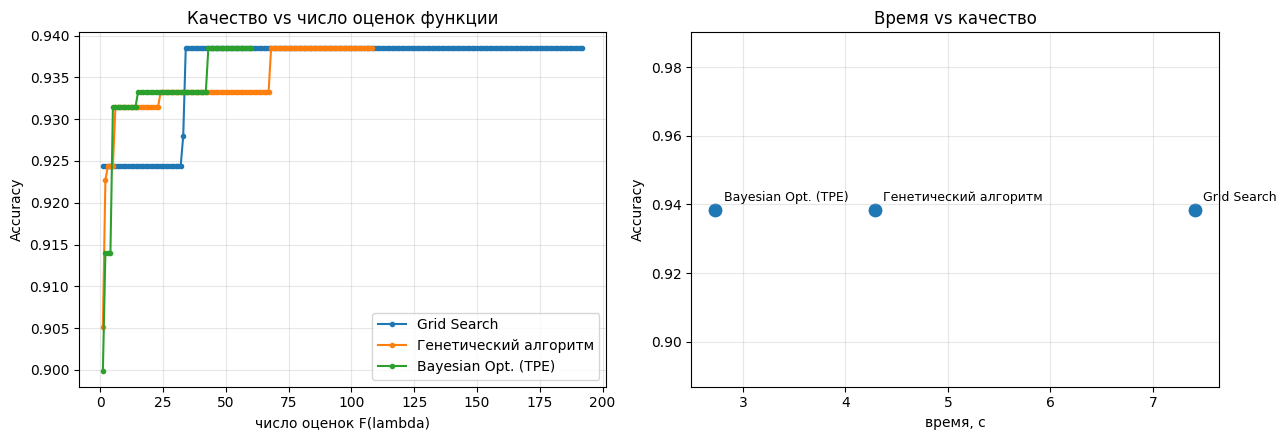

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# (1) качество vs число итераций
axes[0].plot(range(1, len(grid_history) + 1), grid_history,
             label="Grid Search", marker=".")
axes[0].plot(range(1, len(ga_history) + 1), ga_history,
             label="Генетический алгоритм", marker=".")
axes[0].plot(range(1, len(bo_history) + 1), bo_history,
             label="Bayesian Opt. (TPE)", marker=".")
axes[0].set_title("Качество vs число оценок функции")
axes[0].set_xlabel("число оценок F(lambda)")
axes[0].set_ylabel("Accuracy")
axes[0].legend(); axes[0].grid(alpha=0.3)

# (2) время vs качество
axes[1].scatter(results["Время, c"], results["Accuracy"], s=80)
for _, r in results.iterrows():
    axes[1].annotate(r["Метод"], (r["Время, c"], r["Accuracy"]),
                     textcoords="offset points", xytext=(6, 6), fontsize=9)
axes[1].set_title("Время vs качество")
axes[1].set_xlabel("время, c"); axes[1].set_ylabel("Accuracy")
axes[1].grid(alpha=0.3)

plt.tight_layout(); plt.show()

## 9. Выводы

1. **Целевая функция качества $F(\lambda)$ является плохоформализуемой.** Она не
   имеет аналитического выражения, представляет собой композицию «выбор
   гиперпараметров → обучение → метрика», дискретна, негладкая и зашумлена (что
   показано на графике негладкости по `max_depth`).

2. **Аналитическая оптимизация невозможна.** Градиент $\nabla_\lambda F(\lambda)$ не
   определён, поэтому классические градиентные методы неприменимы. Используются
   **эвристические и вероятностные** методы поиска.

3. **Сравнение методов при ограниченном бюджете.**
   - *Grid Search* гарантирует нахождение оптимума только в узлах сетки, а его
     стоимость растёт экспоненциально $O(n^k)$; огрублённая сетка пропускает оптимум
     между узлами.
   - *Генетический алгоритм* и *байесовская оптимизация* достигают сопоставимого или
     лучшего качества при **меньшем числе** оценок функции, так как направленно
     исследуют пространство.
   - *Bayesian Optimization (TPE)* за счёт суррогатной модели и acquisition-функции,
     как правило, наиболее эффективно расходует бюджет.

4. **Итог.** Для плохоформализуемых задач при ограниченном бюджете
   вычислений **эволюционные и байесовские методы эффективнее полного перебора**.